# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [1]:
from imports import *
from vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

## Try with Bayes Agent (Vectorized)

In [2]:
n_agents = 1000
my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True)

In [3]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

 37%|███▋      | 3715/10000 [00:11<00:18, 331.20it/s]


steps:  3716
conclusion:  1.0
conclusion core 1.0


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.944204,0.640251,0.789729,0.395047,0.151162,0.010007,0.973545,0.954168,0.078194,0.928032,...,0.322054,0.724366,0.550969,0.506244,0.839923,0.627519,0.441505,0.568168,0.230947,0.816804
1,0.943355,0.636557,0.757549,0.391230,0.137346,0.009928,0.972920,0.951656,0.067412,0.929093,...,0.330849,0.717931,0.511145,0.518237,0.833363,0.634968,0.443479,0.589617,0.222532,0.799447
2,0.947081,0.645760,0.754599,0.387426,0.122872,0.011910,0.970503,0.949399,0.072618,0.933195,...,0.309951,0.725960,0.501147,0.583456,0.835574,0.655113,0.447431,0.616421,0.208999,0.783612


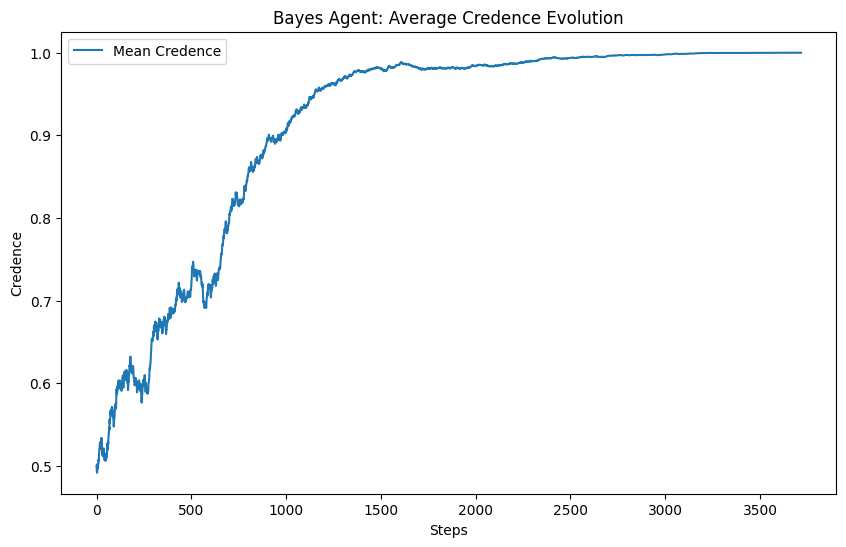

In [4]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [5]:
n_agents = 1000
my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True)

In [6]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:36<00:00, 277.53it/s]


steps:  10000
conclusion:  0.952


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,"[0.2064967975980733, 0.8952494690931779]","[0.8362894449352118, 0.9596129417670505]","[0.9388641136564034, 0.5545650830063287]","[0.6640898906967929, 0.8068693475996396]","[0.7074326563855012, 0.6246361824230526]","[0.03324181834158716, 0.3650994304321518]","[0.5426670265714327, 0.9999999999999984]","[0.5032077224689192, 0.6307388141500111]","[0.9924558741984969, 0.6882078501342027]","[0.4308727335749402, 0.5704325343244333]",...,"[0.5283500911784094, 0.7720188496903388]","[0.4204515165862918, 0.5001508415650823]","[0.43578991264575523, 0.35955445890348703]","[0.8374675065252938, 0.21558880848593479]","[0.9002931274850949, 0.699828549477204]","[0.8371550057894975, 0.5877711576076473]","[0.15610991169549812, 0.12559513915261003]","[0.12555048062579277, 0.12941788946602595]","[0.8669154390765578, 0.3437712107973762]","[0.4447156436152174, 0.6512026391668125]"
1,"[0.49319989980317314, 0.48914950630180404]","[0.4788808196556384, 0.47316392267381713]","[0.4929143891913653, 0.4468930006438967]","[0.49855756751043306, 0.5435016161064798]","[0.5213484845695835, 0.54801434144938]","[0.5078831914002722, 0.5213831308205679]","[0.4691268256176166, 0.43393244878487675]","[0.4927960701574767, 0.5082678288647354]","[0.5836878151373516, 0.5218938438477803]","[0.5368542526387087, 0.5163965553004315]",...,"[0.5044299698318641, 0.4674713837430684]","[0.5047723026365779, 0.4543710587278281]","[0.5160771290748093, 0.5063354970304312]","[0.5192567886034782, 0.5028673158087779]","[0.511822171465919, 0.4736534503545573]","[0.5151972120759621, 0.5448468867631361]","[0.5195541854717306, 0.4784698920091385]","[0.49792798423378043, 0.5004487759255316]","[0.5145089921025203, 0.5036186590090743]","[0.5251856981610606, 0.5097149110778391]"
2,"[0.5383918746125517, 0.5004503081839462]","[0.4921600402953121, 0.503995837621817]","[0.5035211079601785, 0.4945595975157304]","[0.5214833329520789, 0.5425238518479416]","[0.5181172805726415, 0.47082080718942565]","[0.4838762677369014, 0.49989651386499595]","[0.5077112042129216, 0.45597766131238243]","[0.5311275597827737, 0.5373531000871128]","[0.5238353365155238, 0.5041392880626275]","[0.47943636356522606, 0.5285767495975026]",...,"[0.4899946717188496, 0.4974837175720344]","[0.5159317542932824, 0.49945961931017097]","[0.5241462501623848, 0.47597996698214634]","[0.5247800283937135, 0.4806640553286708]","[0.4887377414451562, 0.4858980912702061]","[0.5387829013153577, 0.4847601579204629]","[0.5112048235246675, 0.5148739278379788]","[0.49789138049805, 0.5263635069832661]","[0.5517425365604619, 0.48705174055885864]","[0.5194973069429288, 0.5245826916140618]"


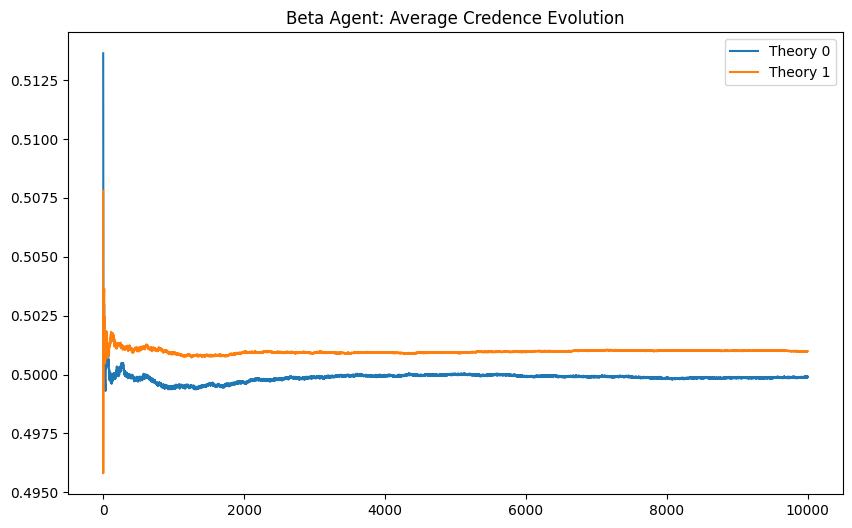

In [7]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

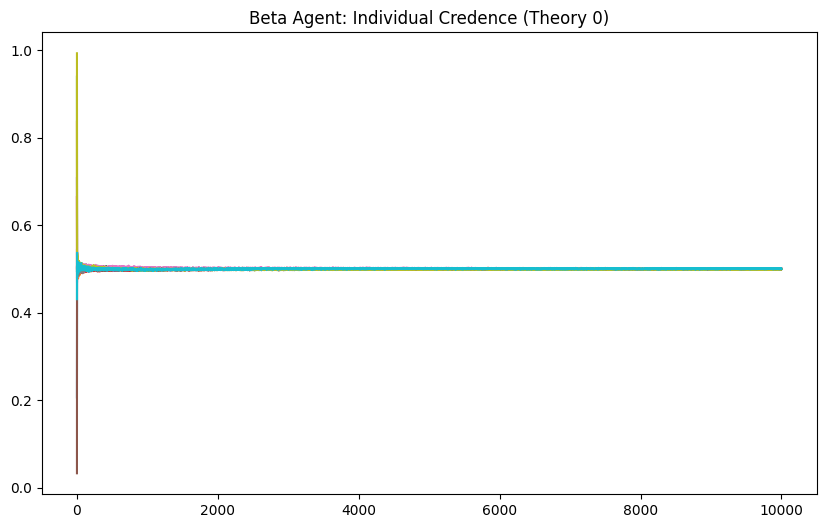

In [8]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()